#TESTS

In [1]:
import sys
sys.path.append('..')

import numpy as np
from PIL import Image
from src.elements import *
from src.systems import *
from src.utilities import *
import matplotlib.pyplot as plt

##Focus

    d_o      d_i  M theory  M matrix   h exp  h meas        S-        S0        S+  result
   75.0   150.00    -2.000    -2.000  3.342x2.834   3.345x2.835      655.9    1080.7    1651.4  FAIL (mag=True, size=True, focus=False)
  100.0   100.00    -1.000    -1.000  1.671x1.417   1.675x1.415      134.3     476.7     295.7  PASS
  150.0    75.00    -0.500    -0.500  0.835x0.708   0.835x0.710       97.9     305.1     169.0  PASS
  250.0    62.50    -0.250    -0.250  0.418x0.354   1.085x0.840       33.8    1142.8     144.5  FAIL (mag=True, size=False, focus=True)


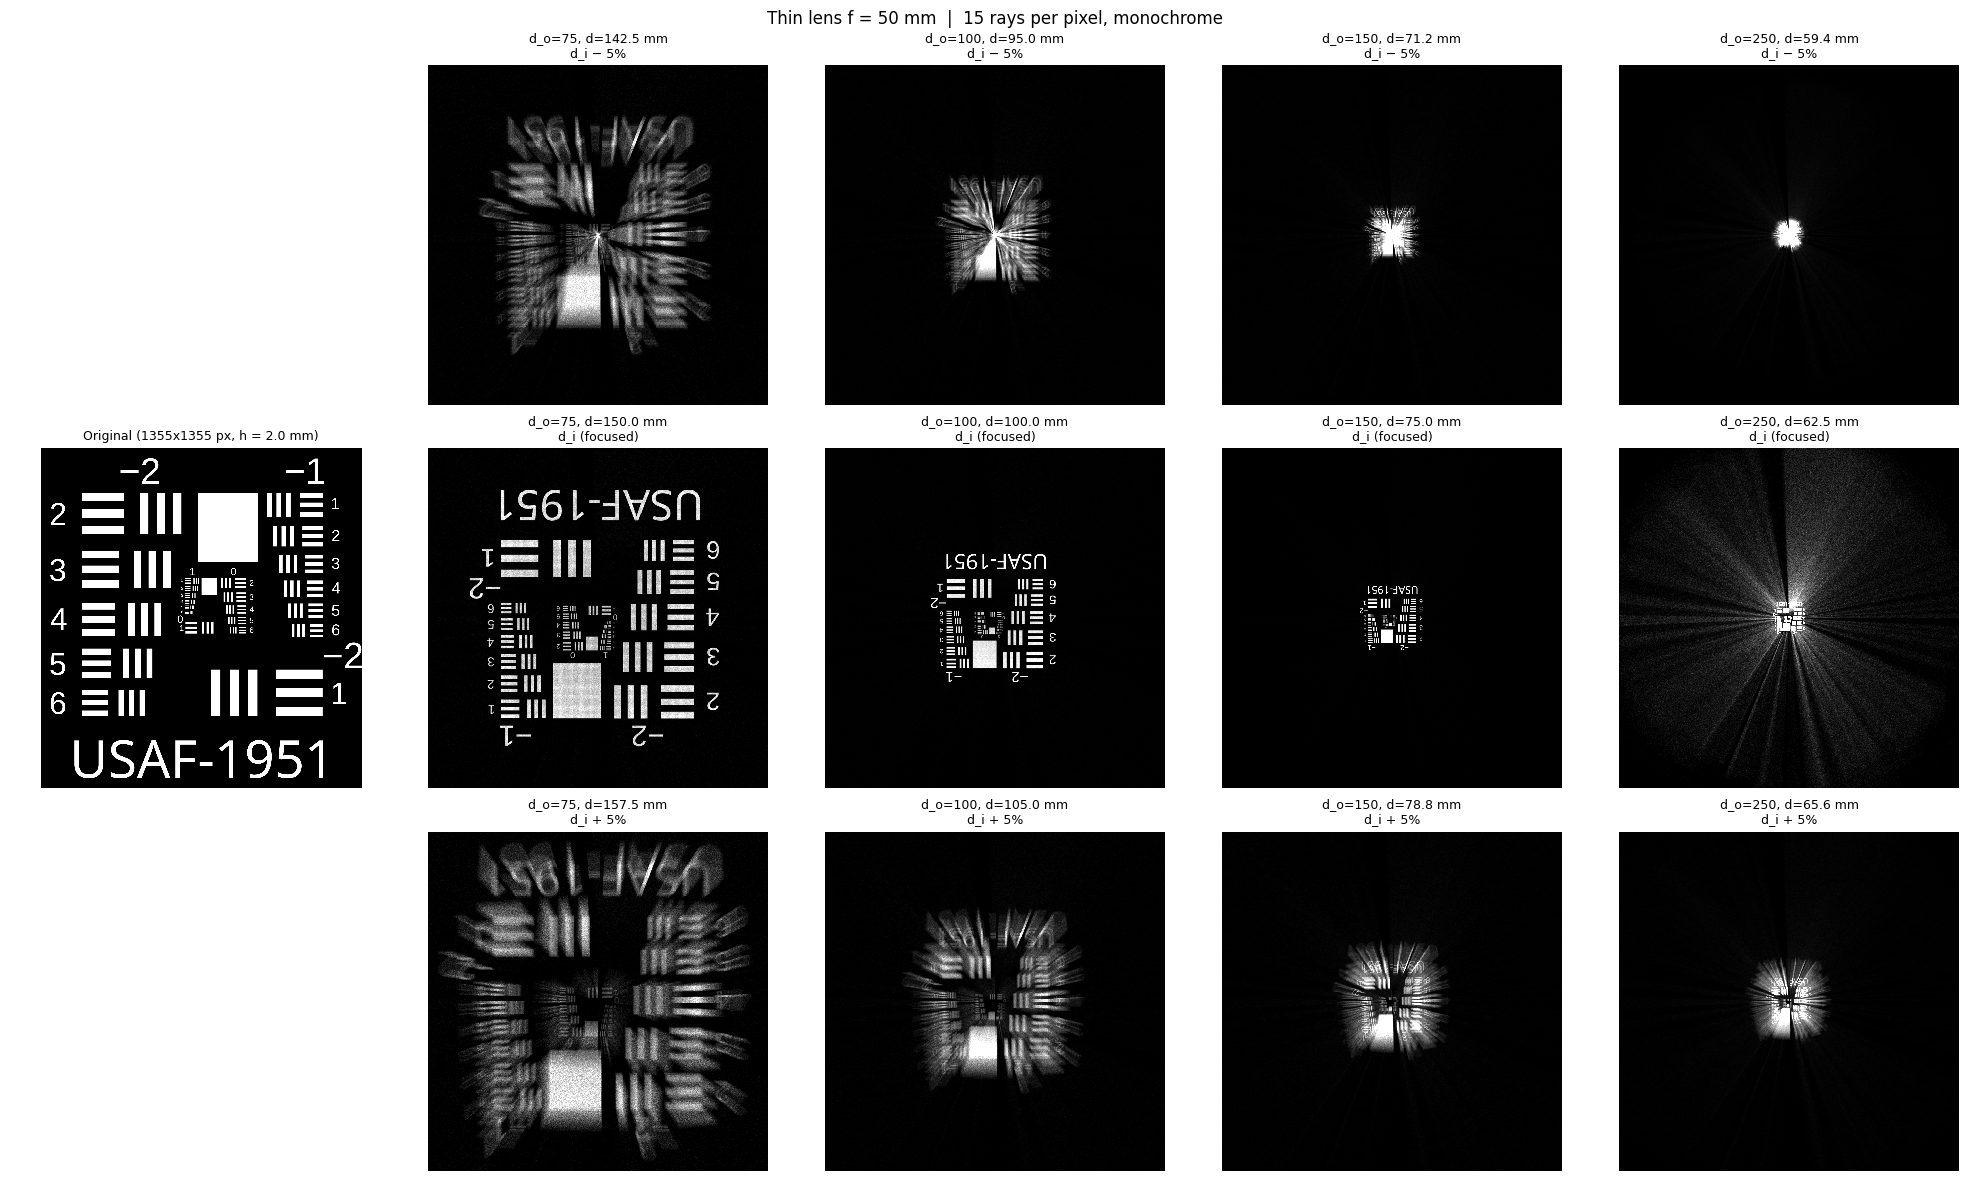

In [2]:
import os
from scipy.ndimage import laplace

# Test object
test_path = '../assets/usaf 1951 medium.jpg'
test_image = Image.open(test_path).convert('L')
test_array = np.array(test_image)
h_obj = 2.0                                           # object height [mm]


def measured_size_px(img, frac=0.5):
    """Height and width (in pixels) of the illuminated region, with edges at frac × peak brightness.
    Uses the mean brightness of each row/column, so a few stray pixels can't move the edge."""
    img = img.astype(np.float32)
    sizes = []
    for axis in (1, 0):                                   # axis=1 -> row profile (height), axis=0 -> column profile (width)
        profile = img.mean(axis=axis)
        lit = np.where(profile > frac * profile.max())[0]
        sizes.append(0 if lit.size == 0 else lit[-1] - lit[0] + 1)
    return sizes                                          # [height_px, width_px]

# Object size measured with the same method used on the images
N_obj = test_array.shape[0]  # Assuming square image
obj_h_px, obj_w_px = measured_size_px(test_array)
obj_extent_mm = np.array([obj_h_px, obj_w_px]) * h_obj / N_obj      # [height_mm, width_mm]


# Lens / sensor parameters
f = 50                                                # thin lens focal length [mm]
pupil_radius = 12.5                                   # 25 mm diameter lens
n_rays_per_pixel = 15
sensor = Sensor(sensor_preset='Ideal_square_5um')    # 1000 x 1000 px, 5 um -> 5 mm field
defocus = 0.05                                        # ±5 % of d_i for the unfocused cases

object_distances = [1.5*f, 2*f, 3*f, 5*f]             # M = -2, -1, -0.5, -0.25

# Output
results_dir = '../results/thin_lens'
os.makedirs(results_dir, exist_ok=True)

def thin_lens_system(f, d_sensor):
    system = OpticalSystem(color=False)
    system.add_element(ThinLens(f))
    system.add_element(FreeSpace(d=d_sensor))
    system.add_element(sensor)
    return system




def sharpness(img):
    return laplace(img.astype(np.float32)).var()      # variance of the Laplacian: higher = sharper

n_cols = len(object_distances) + 1                    # +1 for the original
panel_in = 4                                          # inches per panel
fig, axes = plt.subplots(3, n_cols, figsize=(panel_in*n_cols, panel_in*3))
row_labels = [f'd_i − {defocus*100:.0f}%', 'd_i (focused)', f'd_i + {defocus*100:.0f}%']

# Original object in the first column (middle row), empty cells above and below
for row in range(3):
    axes[row, 0].axis('off')
axes[1, 0].imshow(test_array, cmap='gray', interpolation='nearest')
axes[1, 0].set_title(f'Original ({N_obj}x{N_obj} px, h = {h_obj} mm)', fontsize=9)

print(f"{'d_o':>7} {'d_i':>8} {'M theory':>9} {'M matrix':>9} {'h exp':>7} {'h meas':>7} "
      f"{'S-':>9} {'S0':>9} {'S+':>9}  result")

for i, d_o in enumerate(object_distances):
    col = i + 1
    d_i = 1 / (1/f - 1/d_o)                           # thin lens equation
    M_theory = -d_i / d_o
    test_obj = Object(test_array, distance=d_o, height=h_obj)

    images, sharp = [], []
    for factor in (1 - defocus, 1, 1 + defocus):
        system = thin_lens_system(f, d_i * factor)
        img = system.image_object(test_obj, pupil_radius=pupil_radius,
                                  n_rays_per_pixel=n_rays_per_pixel, interpolation=False)
        images.append(img)
        sharp.append(sharpness(img))
        if factor == 1:
            M_matrix = system.magnification()

    h_expected = abs(M_theory) * obj_extent_mm                          # [height, width] in mm
    h_measured = np.array(measured_size_px(images[1])) * sensor.pixel_size
    ok_size  = np.all(np.abs(h_measured - h_expected) <= 0.02 * h_expected + 2 * sensor.pixel_size)


    ok_mag   = np.isclose(M_matrix, M_theory, rtol=1e-6)
    ok_focus = sharp[1] > sharp[0] and sharp[1] > sharp[2]
    result = 'PASS' if (ok_mag and ok_size and ok_focus) else \
             f"FAIL (mag={ok_mag}, size={ok_size}, focus={ok_focus})"

    print(f"{d_o:7.1f} {d_i:8.2f} {M_theory:9.3f} {M_matrix:9.3f} "
          f"{h_expected[0]:6.3f}x{h_expected[1]:<6.3f} {h_measured[0]:6.3f}x{h_measured[1]:<6.3f} "
          f"{sharp[0]:9.1f} {sharp[1]:9.1f} {sharp[2]:9.1f}  {result}")


    for row, img in enumerate(images):
        ax = axes[row, col]
        ax.imshow(img, cmap='gray', interpolation='nearest')
        ax.set_title(f'd_o={d_o:.0f}, d={d_i*(1 + (row-1)*defocus):.1f} mm\n{row_labels[row]}', fontsize=9)
        ax.axis('off')
        # Each sensor image at its native resolution
        Image.fromarray(img).save(f'{results_dir}/thin_lens_do{d_o:.0f}_{["minus","focus","plus"][row]}.png')

plt.suptitle(f'Thin lens f = {f} mm  |  {n_rays_per_pixel} rays per pixel, monochrome')
plt.tight_layout()

# dpi chosen so each panel holds one figure pixel per sensor pixel
full_res_dpi = max(sensor.resolution) / panel_in      # 1000 px / 4 in = 250 dpi
fig.savefig(f'{results_dir}/thin_lens_test.png', dpi=full_res_dpi, bbox_inches='tight')
plt.show()


#Two lenses

f1 = 50 mm, f2 = 50 mm, d_o = 100 mm
     d       s2      d_i  M theory  M matrix   size exp [mm]  size meas [mm]        S-        S0        S+  result
  50.0   -50.00    25.00    -0.500    -0.500   0.835x0.708     0.835x0.710       107.9     305.7     113.6  PASS
 175.0    75.00   150.00     2.000     2.000   3.342x2.834     3.345x2.835       584.6    1076.7    1695.8  FAIL (mag=True, size=True, focus=False)
 200.0   100.00   100.00     1.000     1.000   1.671x1.417     1.675x1.415       128.8     476.5     333.2  PASS
 250.0   150.00    75.00     0.500     0.500   0.835x0.708     0.835x0.710        66.7     305.9     269.0  PASS
 350.0   250.00    62.50     0.250     0.250   0.418x0.354     1.080x0.830        42.4    1108.0     358.0  FAIL (mag=True, size=False, focus=True)


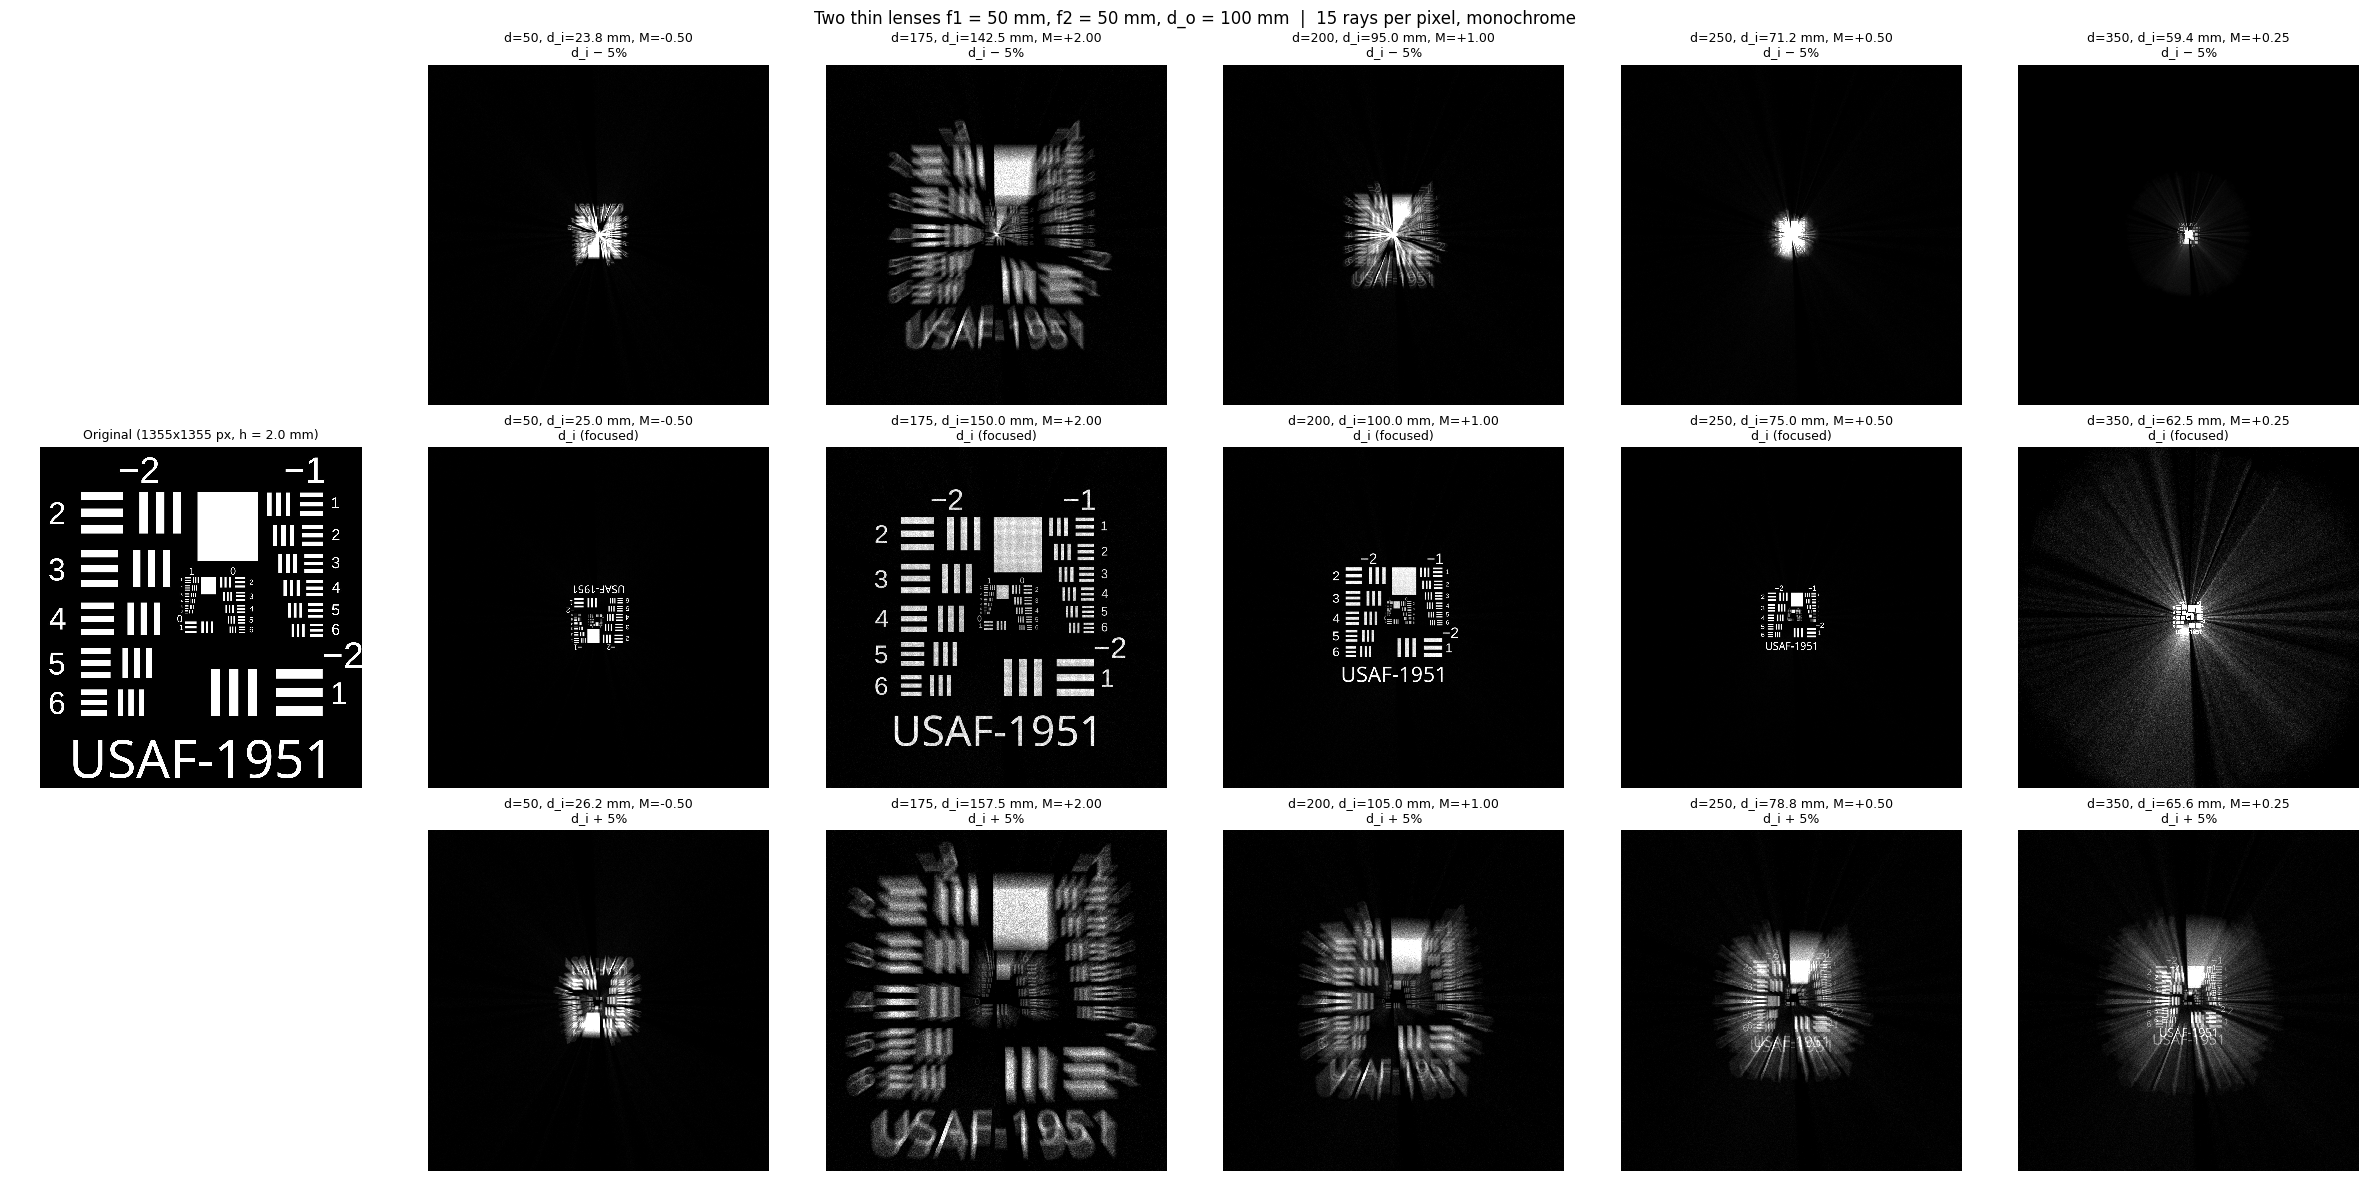

In [3]:
# Two-lens parameters
f1, f2 = 50, 50                                       # focal lengths [mm]
d_o2 = 100                                            # object distance to lens 1 [mm] -> intermediate image at 100 mm, M1 = -1
lens_separations = [50, 175, 200, 250, 350]           # distance between lenses [mm]

results_dir_2 = '../results/two_lenses'
os.makedirs(results_dir_2, exist_ok=True)

def two_lens_theory(f1, f2, d, d_o):
    """Sequential thin-lens equation. Returns intermediate image s1', object distance for lens 2 s2,
    final image distance s2' (from lens 2) and total magnification."""
    s1p = 1 / (1/f1 - 1/d_o)                          # image distance of lens 1
    s2  = d - s1p                                     # object distance for lens 2 (negative -> virtual object)
    s2p = 1 / (1/f2 - 1/s2)                           # image distance of lens 2
    M   = (-s1p / d_o) * (-s2p / s2)                  # M1 * M2
    return s1p, s2, s2p, M

def two_lens_system(f1, f2, d, d_sensor):
    system = OpticalSystem(color=False)
    system.add_element(ThinLens(f1))
    system.add_element(FreeSpace(d=d))
    system.add_element(ThinLens(f2))
    system.add_element(FreeSpace(d=d_sensor))
    system.add_element(sensor)
    return system

obj_h_px, obj_w_px = measured_size_px(test_array)
obj_extent_mm = np.array([obj_h_px, obj_w_px]) * h_obj / N_obj

n_cols = len(lens_separations) + 1
fig, axes = plt.subplots(3, n_cols, figsize=(panel_in*n_cols, panel_in*3))
row_labels = [f'd_i − {defocus*100:.0f}%', 'd_i (focused)', f'd_i + {defocus*100:.0f}%']

for row in range(3):
    axes[row, 0].axis('off')
axes[1, 0].imshow(test_array, cmap='gray', interpolation='nearest')
axes[1, 0].set_title(f'Original ({N_obj}x{N_obj} px, h = {h_obj} mm)', fontsize=9)

print(f"f1 = {f1} mm, f2 = {f2} mm, d_o = {d_o2} mm")
print(f"{'d':>6} {'s2':>8} {'d_i':>8} {'M theory':>9} {'M matrix':>9} {'size exp [mm]':>15} {'size meas [mm]':>15} "
      f"{'S-':>9} {'S0':>9} {'S+':>9}  result")

test_obj2 = Object(test_array, distance=d_o2, height=h_obj)

for i, d in enumerate(lens_separations):
    col = i + 1
    s1p, s2, d_i, M_theory = two_lens_theory(f1, f2, d, d_o2)
    if d_i <= 0:
        print(f"{d:6.1f}  virtual final image (d_i = {d_i:.1f} mm) – skipped")
        continue

    images, sharp = [], []
    for factor in (1 - defocus, 1, 1 + defocus):
        system = two_lens_system(f1, f2, d, d_i * factor)
        img = system.image_object(test_obj2, pupil_radius=pupil_radius,
                                  n_rays_per_pixel=n_rays_per_pixel, interpolation=False)
        images.append(img)
        sharp.append(sharpness(img))
        if factor == 1:
            M_matrix = system.magnification()

    size_expected = abs(M_theory) * obj_extent_mm
    size_measured = np.array(measured_size_px(images[1])) * sensor.pixel_size

    ok_mag   = np.isclose(M_matrix, M_theory, rtol=1e-6)
    ok_size  = np.all(np.abs(size_measured - size_expected) <= 0.02 * size_expected + 2 * sensor.pixel_size)
    ok_focus = sharp[1] > sharp[0] and sharp[1] > sharp[2]
    result = 'PASS' if (ok_mag and ok_size and ok_focus) else \
             f"FAIL (mag={ok_mag}, size={ok_size}, focus={ok_focus})"

    print(f"{d:6.1f} {s2:8.2f} {d_i:8.2f} {M_theory:9.3f} {M_matrix:9.3f} "
          f"{size_expected[0]:7.3f}x{size_expected[1]:<7.3f} {size_measured[0]:7.3f}x{size_measured[1]:<7.3f} "
          f"{sharp[0]:9.1f} {sharp[1]:9.1f} {sharp[2]:9.1f}  {result}")

    for row, img in enumerate(images):
        ax = axes[row, col]
        ax.imshow(img, cmap='gray', interpolation='nearest')
        ax.set_title(f'd={d:.0f}, d_i={d_i*(1 + (row-1)*defocus):.1f} mm, M={M_theory:+.2f}\n{row_labels[row]}',
                     fontsize=9)
        ax.axis('off')
        Image.fromarray(img).save(f'{results_dir_2}/two_lenses_d{d:.0f}_{["minus","focus","plus"][row]}.png')

plt.suptitle(f'Two thin lenses f1 = {f1} mm, f2 = {f2} mm, d_o = {d_o2} mm  |  '
             f'{n_rays_per_pixel} rays per pixel, monochrome')
plt.tight_layout()
fig.savefig(f'{results_dir_2}/two_lenses_test.png', dpi=max(sensor.resolution) / panel_in, bbox_inches='tight')
plt.show()


##Magnification

Sensor: 2048×2048 px, 6.5 µm → 13.31×13.31 mm
Franja en el objeto: 185.3 px = 27.35 µm
 M nom   f_obj    NA  M matriz  L img [µm]  M medida  error %
    5x   40.00  0.12    -5.000      138.51     5.064     1.28
   10x   20.00  0.25   -10.000      273.21     9.989    -0.11
   20x   10.00  0.40   -20.000      546.56    19.984    -0.08
   40x    5.00  0.65   -40.000     1092.52    39.945    -0.14
   60x    3.33  0.85   -60.000     1635.67    59.805    -0.33


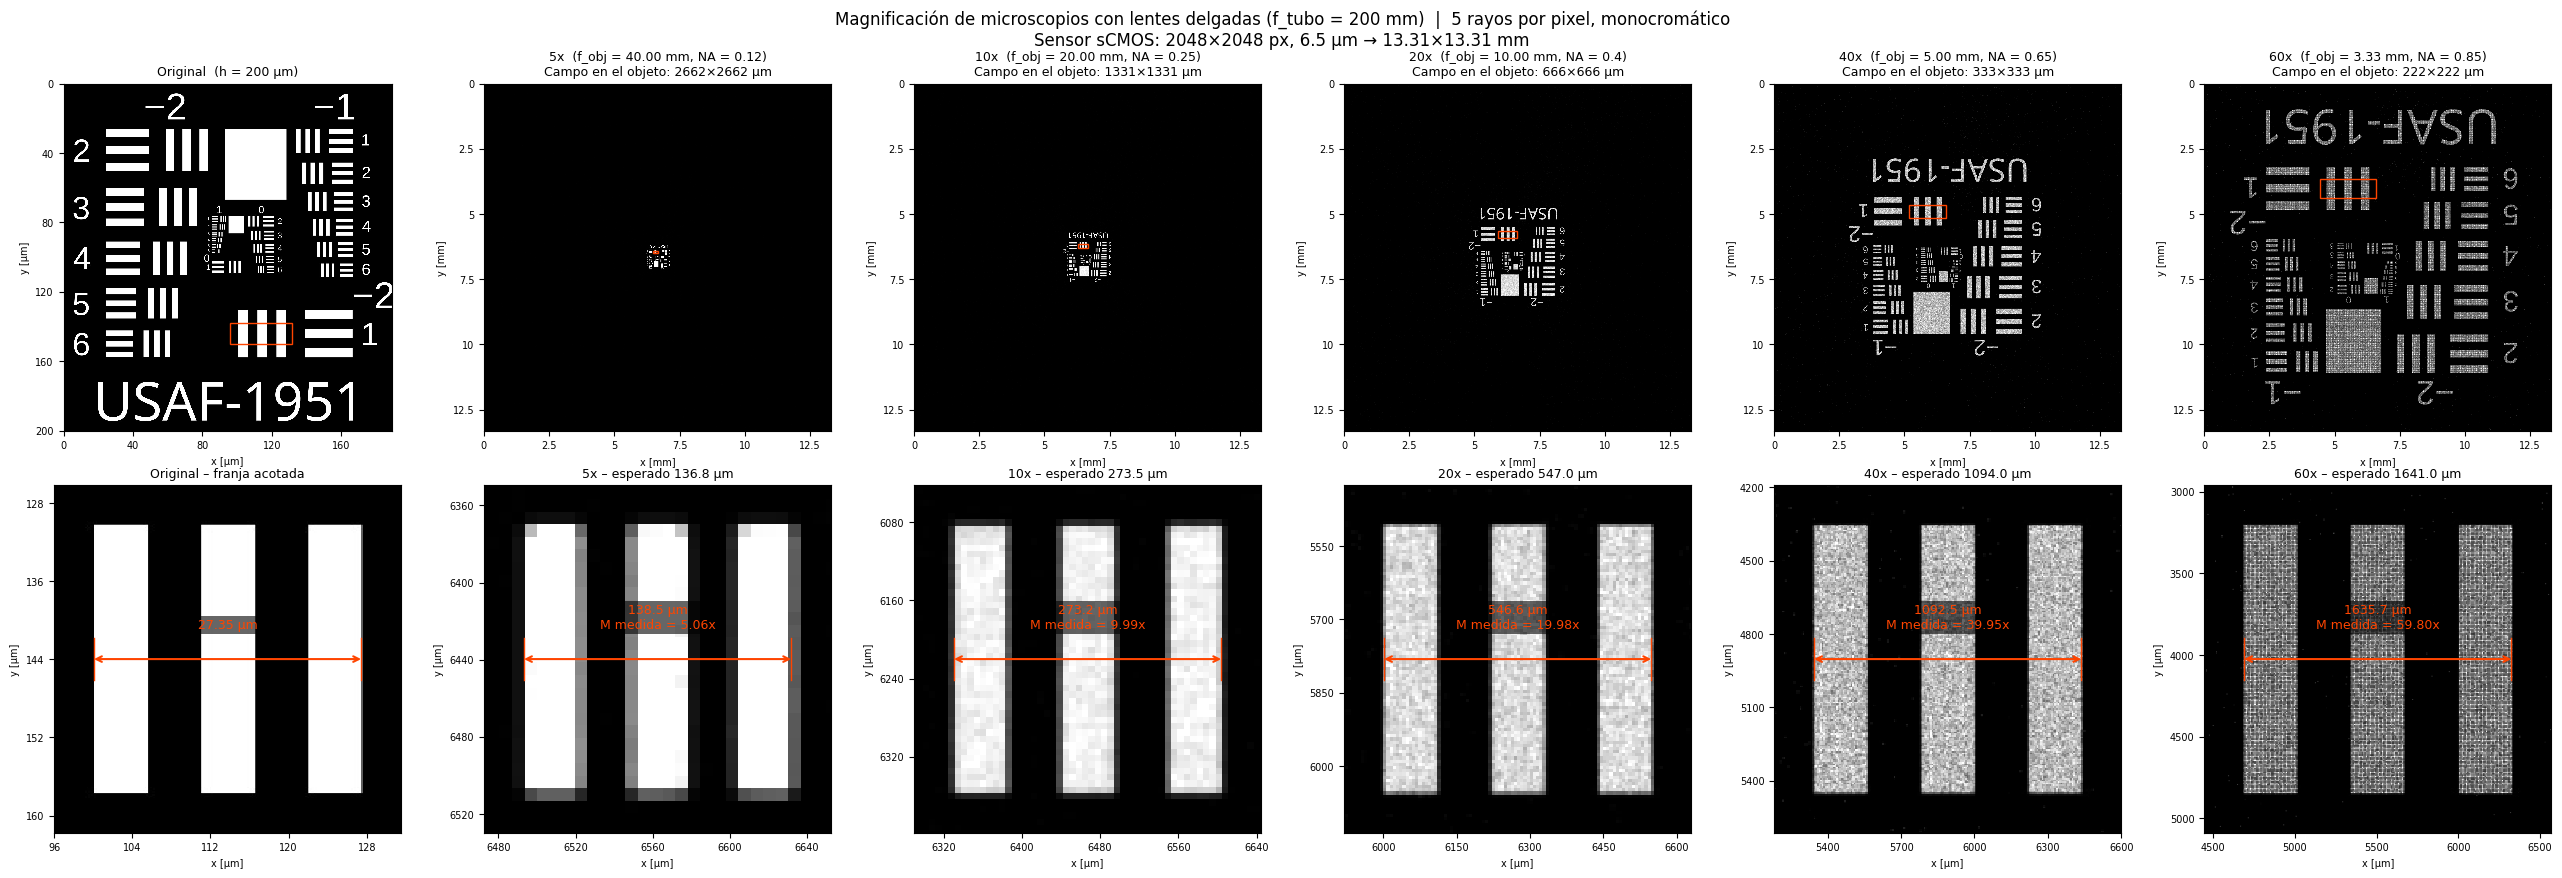

In [4]:
import os
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator, FixedLocator, FuncFormatter

def physical_axes(ax, pixel_size, unit='mm', scale=1, origin=-0.5, nbins=5, fontsize=7):
    """Ticks in physical units on a pixel image.
    pixel_size in mm; scale=1 -> mm, scale=1000 -> µm. origin = coordinate (px) taken as 0.
    Call AFTER setting the axis limits (zoom)."""
    k = pixel_size * scale                                    # physical units per pixel
    for axis, lims in ((ax.xaxis, ax.get_xlim()), (ax.yaxis, ax.get_ylim())):
        lo, hi = sorted(lims)
        phys = MaxNLocator(nbins).tick_values((lo - origin) * k, (hi - origin) * k)
        ticks_px = phys / k + origin
        axis.set_major_locator(FixedLocator(ticks_px[(ticks_px >= lo) & (ticks_px <= hi)]))
        axis.set_major_formatter(FuncFormatter(lambda v, pos: f'{round((v - origin) * k, 6):g}'))
    ax.set_xlabel(f'x [{unit}]', fontsize=fontsize)
    ax.set_ylabel(f'y [{unit}]', fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)

# Object: USAF pattern
usaf_path = '../assets/usaf 1951 medium.jpg'
usaf_array = np.array(Image.open(usaf_path).convert('L'))     # 1355 x 1280 px, white bars on black background
H_obj, W_obj = usaf_array.shape
h_obj = 0.2                                                   # physical object height [mm] -> at 60x it spans 12 mm (fits on the sCMOS)
p_obj = h_obj / H_obj                                         # object pixel size [mm] (same as in object_rays)

# Stripe to dimension: 3 vertical bars of group -2, element 1
stripe_row  = 975                                             # row (object px) where the dimension line runs
stripe_cols = (650, 890)                                      # column search window (object px)
band = 40                                                     # ± rows averaged for the profile

# Microscopes
f_tube = 200
magnifications = [5, 10, 20, 40, 60]
NA_values = {5: 0.12, 10: 0.25, 20: 0.40, 40: 0.65, 60: 0.85}  # typical NA of dry objectives
n_rays_per_pixel = 5
sensor_m = Sensor(sensor_preset='Microscopy_SCMOS')           # 2048 x 2048 px, 6.5 um
Ws, Hs = sensor_m.resolution
sensor_w_mm = Ws * sensor_m.pixel_size
sensor_h_mm = Hs * sensor_m.pixel_size
sensor_info = f'{Ws}×{Hs} px, {sensor_m.pixel_size*1000:.1f} µm → {sensor_w_mm:.2f}×{sensor_h_mm:.2f} mm'

results_dir_m = '../results/microscopes'
os.makedirs(results_dir_m, exist_ok=True)

def microscope(f_obj, f_tube, sensor):
    system = OpticalSystem(color=False)
    system.add_element(ThinLens(f_obj))
    system.add_element(FreeSpace(f_obj + f_tube))
    system.add_element(ThinLens(f_tube))
    system.add_element(FreeSpace(f_tube))
    system.add_element(sensor)
    return system

def stripe_edges(profile):
    """Subpixel edges of the stripe: first rising and last falling crossing at 50 % of the maximum."""
    p = profile.astype(np.float32)
    half = 0.5 * p.max()
    idx = np.where(p > half)[0]
    if idx.size == 0:
        return np.nan, np.nan
    i0, i1 = idx[0], idx[-1]
    left  = i0 - 1 + (half - p[i0-1]) / (p[i0] - p[i0-1]) if i0 > 0 else float(i0)
    right = i1 + (p[i1] - half) / (p[i1] - p[i1+1]) if i1 < p.size - 1 else float(i1)
    return left, right

def obj_to_sensor(i, j, M):
    """Sensor position (row, column) of object pixel (i, j) for a magnification M."""
    x = (j - W_obj/2) * p_obj
    y = (i - H_obj/2) * p_obj
    return M*y/sensor_m.pixel_size + Hs/2, M*x/sensor_m.pixel_size + Ws/2

def draw_cota(ax, x0, x1, y, label, color='orangered', tick=None):
    tick = tick or 0.15 * abs(x1 - x0)
    ax.annotate('', xy=(x0, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, shrinkA=0, shrinkB=0))
    ax.plot([x0, x0], [y - tick, y + tick], color=color, lw=1)
    ax.plot([x1, x1], [y - tick, y + tick], color=color, lw=1)
    ax.text((x0 + x1)/2, y - 1.3*tick, label, color=color, ha='center', va='bottom', fontsize=9,
            bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=2))

def zoom(ax, cx, cy, half):
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy + half, cy - half)                         # y axis inverted in images

# Stripe in the original
c0, c1 = stripe_cols
left_o, right_o = stripe_edges(usaf_array[stripe_row-band:stripe_row+band, c0:c1].mean(axis=0))
left_o += c0; right_o += c0
L_obj_mm = (right_o - left_o) * p_obj

n_cols = len(magnifications) + 1
fig, axes = plt.subplots(2, n_cols, figsize=(4.3*n_cols, 8.8))

axes[0, 0].imshow(usaf_array, cmap='gray', interpolation='nearest')
axes[0, 0].add_patch(mpatches.Rectangle((c0, stripe_row-band), c1-c0, 2*band, fill=False, edgecolor='orangered'))
axes[0, 0].set_title(f'Original  (h = {h_obj*1000:.0f} µm)', fontsize=9)
physical_axes(axes[0, 0], p_obj, unit='µm', scale=1000)

axes[1, 0].imshow(usaf_array, cmap='gray', interpolation='nearest')
span_o = right_o - left_o
draw_cota(axes[1, 0], left_o, right_o, stripe_row, f'{L_obj_mm*1000:.2f} µm', tick=0.08*span_o)
zoom(axes[1, 0], (left_o + right_o)/2, stripe_row, 0.65*span_o)
physical_axes(axes[1, 0], p_obj, unit='µm', scale=1000)
axes[1, 0].set_title('Original – franja acotada', fontsize=9)

print(f"Sensor: {sensor_info}")
print(f"Franja en el objeto: {right_o - left_o:.1f} px = {L_obj_mm*1000:.2f} µm")
print(f"{'M nom':>6} {'f_obj':>7} {'NA':>5} {'M matriz':>9} {'L img [µm]':>11} {'M medida':>9} {'error %':>8}")

for idx_m, M_nom in enumerate(magnifications):
    col = idx_m + 1
    f_obj = f_tube / M_nom
    NA = NA_values[M_nom]
    pupil_radius_m = f_obj * np.tan(np.arcsin(NA))

    system = microscope(f_obj, f_tube, sensor_m)
    M_mat = system.magnification()                            # = -f_tube / f_obj
    obj = Object(usaf_array, distance=f_obj, height=h_obj)
    img = system.image_object(obj, pupil_radius=pupil_radius_m,
                              n_rays_per_pixel=n_rays_per_pixel, interpolation=False)

    # Predicted stripe window on the sensor (M < 0 -> inverted image, hence sorted)
    r_a, c_a = obj_to_sensor(stripe_row - band, stripe_cols[0], M_mat)
    r_b, c_b = obj_to_sensor(stripe_row + band, stripe_cols[1], M_mat)
    r0, r1 = sorted([r_a, r_b]); s0, s1 = sorted([c_a, c_b])
    r0, s0 = int(max(np.floor(r0), 0)), int(max(np.floor(s0), 0))
    r1, s1 = int(min(np.ceil(r1) + 1, Hs)), int(min(np.ceil(s1) + 1, Ws))

    left_i, right_i = stripe_edges(img[r0:r1, s0:s1].mean(axis=0))
    left_i += s0; right_i += s0
    L_img_mm = (right_i - left_i) * sensor_m.pixel_size
    M_meas = L_img_mm / L_obj_mm
    err = 100 * (M_meas - abs(M_mat)) / abs(M_mat)

    print(f"{M_nom:>5}x {f_obj:7.2f} {NA:5.2f} {M_mat:9.3f} {L_img_mm*1000:11.2f} {M_meas:9.3f} {err:8.2f}")

    # Row 0: full sensor with axes in mm
    ax0 = axes[0, col]
    ax0.imshow(img, cmap='gray', interpolation='nearest')
    ax0.add_patch(mpatches.Rectangle((s0, r0), s1-s0, r1-r0, fill=False, edgecolor='orangered'))
    physical_axes(ax0, sensor_m.pixel_size, unit='mm', nbins=6)
    fov_w, fov_h = sensor_w_mm / abs(M_mat), sensor_h_mm / abs(M_mat)
    ax0.set_title(f'{M_nom}x  (f_obj = {f_obj:.2f} mm, NA = {NA})\n'
                  f'Campo en el objeto: {fov_w*1000:.0f}×{fov_h*1000:.0f} µm', fontsize=9)

    # Row 1: zoom with dimension line (sensor axes in µm)
    ax1 = axes[1, col]
    y_cota = obj_to_sensor(stripe_row, 0, M_mat)[0]
    span_i = right_i - left_i
    ax1.imshow(img, cmap='gray', interpolation='nearest')
    draw_cota(ax1, left_i, right_i, y_cota,
              f'{L_img_mm*1000:.1f} µm\nM medida = {M_meas:.2f}x', tick=0.08*span_i)
    zoom(ax1, (left_i + right_i)/2, y_cota, 0.65*span_i)
    physical_axes(ax1, sensor_m.pixel_size, unit='µm', scale=1000)
    ax1.set_title(f'{M_nom}x – esperado {abs(M_mat)*L_obj_mm*1000:.1f} µm', fontsize=9)

plt.suptitle(f'Magnificación de microscopios con lentes delgadas (f_tubo = {f_tube} mm)  |  '
             f'{n_rays_per_pixel} rayos por pixel, monocromático\nSensor sCMOS: {sensor_info}')
plt.tight_layout()
fig.savefig(f'{results_dir_m}/magnificacion_cotas.png', dpi=250, bbox_inches='tight')
plt.show()

##Runtime test

Microscopio 20x (f_obj = 10.0 mm, NA = 0.4) | Sensor: 2048×2048 px, 6.5 µm → 13.31×13.31 mm
 imagen    px objeto  px emisores rayos/px       rayos  tiempo [s]  µs/rayo
  small   500x530          75,289        5     376,445        5.26    13.98
  small   500x530          75,289        9     677,601        8.68    12.80
  small   500x530          75,289       15   1,129,335       13.82    12.24
 medium  1280x1355        403,118        5   2,015,590       28.37    14.08
 medium  1280x1355        403,118        9   3,628,062       47.91    13.21
 medium  1280x1355        403,118       15   6,046,770      117.20    19.38
  large  3840x4064      3,190,952        5  15,954,760      228.27    14.31
  large  3840x4064      3,190,952        9  28,718,568   saltado (> MAX_RAYS)
  large  3840x4064      3,190,952       15  47,864,280   saltado (> MAX_RAYS)


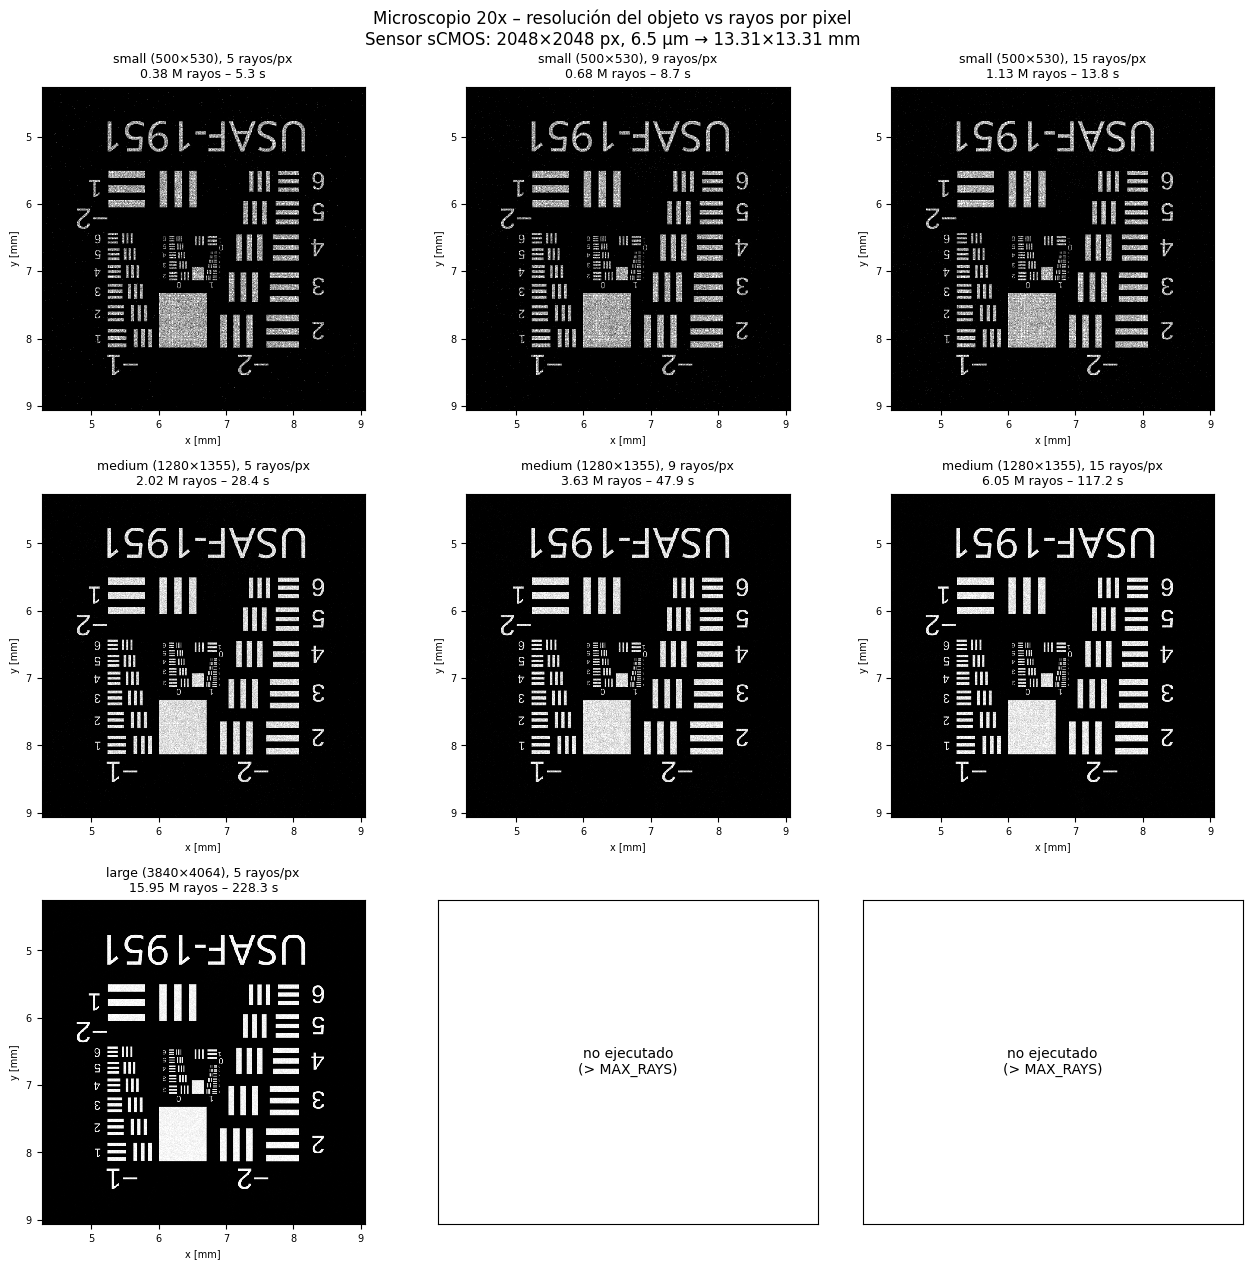

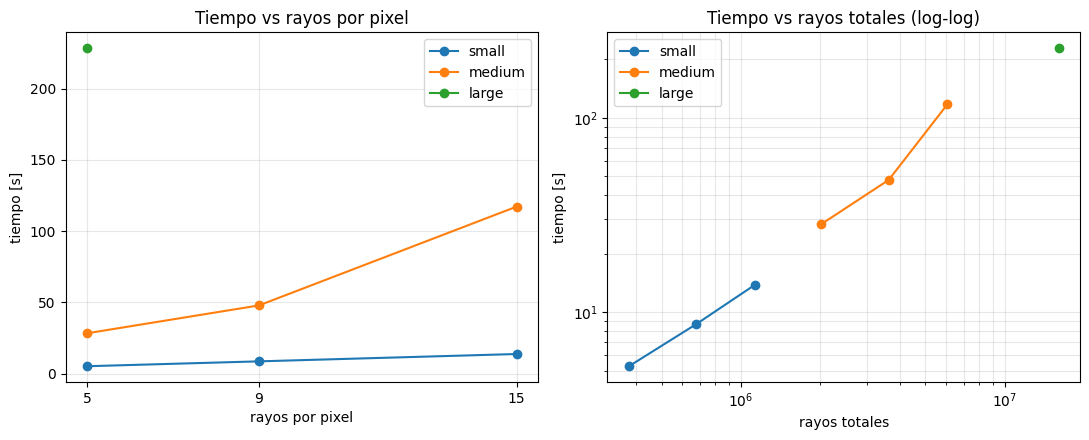

In [6]:
import time, gc

# Runtime test: 20x with 3 USAF resolutions and 5 / 9 / 15 rays
usaf_files = {
    'small':  '../assets/usaf 1951 small.jpg',    #  500 x  530 px
    'medium': '../assets/usaf 1951 medium.jpg',   # 1280 x 1355 px
    'large':  '../assets/usaf 1951.jpg',          # 3840 x 4064 px
}
rays_list = [5, 9, 15]
M_test = 20
h_obj_t = 0.2                                     # same physical height for the 3 images [mm]
MAX_RAYS = 20e6                                   # safety limit (memory): cases exceeding it are skipped

f_obj_t = f_tube / M_test
pupil_t = f_obj_t * np.tan(np.arcsin(NA_values[M_test]))
system_t = microscope(f_obj_t, f_tube, sensor_m)

usaf_arrays = {name: np.array(Image.open(path).convert('L')) for name, path in usaf_files.items()}

timing = {}                                       # (name, n_rays) -> dict with results
outputs = {}

print(f"Microscopio {M_test}x (f_obj = {f_obj_t} mm, NA = {NA_values[M_test]}) | Sensor: {sensor_info}")
print(f"{'imagen':>7} {'px objeto':>12} {'px emisores':>12} {'rayos/px':>8} {'rayos':>11} {'tiempo [s]':>11} {'µs/rayo':>8}")

for name, arr in usaf_arrays.items():
    n_emit = int((arr > 0).sum())                 # only pixels with intensity > 0 generate rays
    for n_rays in rays_list:
        n_total = n_emit * n_rays
        if n_total > MAX_RAYS:
            print(f"{name:>7} {arr.shape[1]:>5}x{arr.shape[0]:<6} {n_emit:>12,} {n_rays:>8} {n_total:>11,}   saltado (> MAX_RAYS)")
            continue

        obj_t = Object(arr, distance=f_obj_t, height=h_obj_t)
        gc.collect()
        t0 = time.perf_counter()
        img = system_t.image_object(obj_t, pupil_radius=pupil_t, n_rays_per_pixel=n_rays, interpolation=False)
        dt = time.perf_counter() - t0

        timing[(name, n_rays)] = dict(n_total=n_total, t=dt)
        outputs[(name, n_rays)] = img
        print(f"{name:>7} {arr.shape[1]:>5}x{arr.shape[0]:<6} {n_emit:>12,} {n_rays:>8} {n_total:>11,} {dt:11.2f} {dt/n_total*1e6:8.2f}")

        Image.fromarray(img).save(f'{results_dir_m}/tiempos_{M_test}x_{name}_{n_rays}rayos.png')
        del obj_t; gc.collect()

# Figure 1: output images (rows = resolution, columns = rays/px)
half_img_px = 0.6 * M_test * h_obj_t / sensor_m.pixel_size      # crop around the pattern image
fig, axes = plt.subplots(len(usaf_files), len(rays_list), figsize=(4.3*len(rays_list), 4.3*len(usaf_files)))
for r, name in enumerate(usaf_files):
    for c, n_rays in enumerate(rays_list):
        ax = axes[r, c]
        if (name, n_rays) not in outputs:
            ax.text(0.5, 0.5, 'no ejecutado\n(> MAX_RAYS)', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        ax.imshow(outputs[(name, n_rays)], cmap='gray', interpolation='nearest')
        zoom(ax, Ws/2, Hs/2, half_img_px)
        physical_axes(ax, sensor_m.pixel_size, unit='mm')
        tr = timing[(name, n_rays)]
        ax.set_title(f'{name} ({usaf_arrays[name].shape[1]}×{usaf_arrays[name].shape[0]}), {n_rays} rayos/px\n'
                     f'{tr["n_total"]/1e6:.2f} M rayos – {tr["t"]:.1f} s', fontsize=9)

plt.suptitle(f'Microscopio {M_test}x – resolución del objeto vs rayos por pixel\nSensor sCMOS: {sensor_info}')
plt.tight_layout()
fig.savefig(f'{results_dir_m}/tiempos_{M_test}x_imagenes.png', dpi=250, bbox_inches='tight')
plt.show()

# Figure 2: timings
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.5))
for name in usaf_files:
    ns = [n for n in rays_list if (name, n) in timing]
    if not ns:
        continue
    axA.plot(ns, [timing[(name, n)]['t'] for n in ns], 'o-', label=name)
    axB.loglog([timing[(name, n)]['n_total'] for n in ns], [timing[(name, n)]['t'] for n in ns], 'o-', label=name)
axA.set_xlabel('rayos por pixel'); axA.set_ylabel('tiempo [s]'); axA.set_xticks(rays_list)
axA.set_title('Tiempo vs rayos por pixel'); axA.grid(alpha=0.3); axA.legend()
axB.set_xlabel('rayos totales'); axB.set_ylabel('tiempo [s]')
axB.set_title('Tiempo vs rayos totales (log-log)'); axB.grid(alpha=0.3, which='both'); axB.legend()
plt.tight_layout()
fig.savefig(f'{results_dir_m}/tiempos_{M_test}x_grafica.png', dpi=200, bbox_inches='tight')
plt.show()
